In [2]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

# Suppress TF hardware logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("TensorFlow Version:", tf.__version__)
print("Running setup complete!")

TensorFlow Version: 2.22.0-rc0
Running setup complete!


In [3]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import matplotlib.pyplot as plt

# Suppress TF hardware logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

print("TensorFlow Version:", tf.__version__)
print("Running setup complete!")

TensorFlow Version: 2.22.0-rc0
Running setup complete!


## Load the shared dataset split

Load the saved CSV manifest used across the team's models so training,
validation and test sets are identical for every model comparison.

In [4]:
from pathlib import Path
import pandas as pd

# Locate the project folder.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

data_dir = project_dir / "data"
manifest_path = project_dir / "splits" / "brain_tumor_split_seed123.csv"

# Read the shared split instead of creating a new one.
manifest_df = pd.read_csv(manifest_path)

class_names = ["glioma", "meningioma", "notumor", "pituitary"]
num_classes = len(class_names)

train_df = manifest_df[manifest_df["split"] == "train"].copy()
val_df = manifest_df[manifest_df["split"] == "validation"].copy()
test_df = manifest_df[manifest_df["split"] == "test"].copy()

print("Training images:", len(train_df))
print("Validation images:", len(val_df))
print("Testing images:", len(test_df))
print("Classes:", class_names)

Training images: 4343
Validation images: 1086
Testing images: 1584
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


## Build the training, validation and test datasets

Load images from the file paths in the shared CSV, resize them to a
common `img_size`, and batch them for training. Only the training
split is shuffled; validation and test keep their saved order.

In [5]:
img_size = (224, 224)
BATCH_SIZE = 32
SEED = 123

tf.keras.utils.set_random_seed(SEED)


def load_image(image_path, label):
    image_bytes = tf.io.read_file(image_path)

    image = tf.io.decode_image(
        image_bytes,
        channels=3,
        expand_animations=False,
    )
    image.set_shape([None, None, 3])

    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)

    return image, label


def make_dataset(dataframe, training=False):
    paths = [
        str(data_dir / relative_path)
        for relative_path in dataframe["relative_path"]
    ]
    labels = dataframe["class_id"].to_numpy(dtype="int32")

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    # Change training order each epoch without changing split membership.
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True,
        )

    dataset = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df)
test_ds = make_dataset(test_df)

# Check one training batch.
images, labels = next(iter(train_ds))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image data type:", images.dtype)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image data type: <dtype: 'float32'>


In [7]:
model2 = models.Sequential([
    # Input Scaling
    layers.Rescaling(1./255, input_shape=(img_size[0], img_size[1], 3)),
    
    # Block 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    
    # Block 2
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),
    
    # Block 3
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),
    
    # Dense Layers
    layers.Flatten(),
    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    
    # Output Layer
    layers.Dense(num_classes, activation='softmax')
])

model2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,786,564 (98.37 MB)

 Trainable params: 25,785,604 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [8]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

epochs = 25
history = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/25


c:\Users\palit\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


136/136 ━━━━━━━━━━━━━━━━━━━━ 216s 2s/step - accuracy: 0.7562 - loss: 1.8507 - val_accuracy: 0.2726 - val_loss: 19.6339
Epoch 2/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 220s 2s/step - accuracy: 0.8232 - loss: 1.5803 - val_accuracy: 0.5727 - val_loss: 2.0849
Epoch 3/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 222s 2s/step - accuracy: 0.8632 - loss: 1.3238 - val_accuracy: 0.7689 - val_loss: 1.6279
Epoch 4/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.8934 - loss: 1.1654 - val_accuracy: 0.8002 - val_loss: 1.3437
Epoch 5/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 249s 2s/step - accuracy: 0.9024 - loss: 1.0928 - val_accuracy: 0.6565 - val_loss: 2.6766
Epoch 6/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 255s 2s/step - accuracy: 0.9090 - loss: 1.1546 - val_accuracy: 0.7007 - val_loss: 1.9880
Epoch 7/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 264s 2s/step - accuracy: 0.9328 - loss: 1.0572 - val_accuracy: 0.4576 - val_loss: 2.4804
Epoch 8/25
136/136 ━━━━━━━━━━━━━━━━━━━━ 234s 2s/step - accuracy: 0.9362 - loss: 1.0560 - val_accuracy: 0.87

In [9]:

test_loss, test_acc = model2.evaluate(test_ds)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 300ms/step - accuracy: 0.8346 - loss: 1.5440

Final Test Accuracy: 0.8346
Final Test Loss: 1.5440


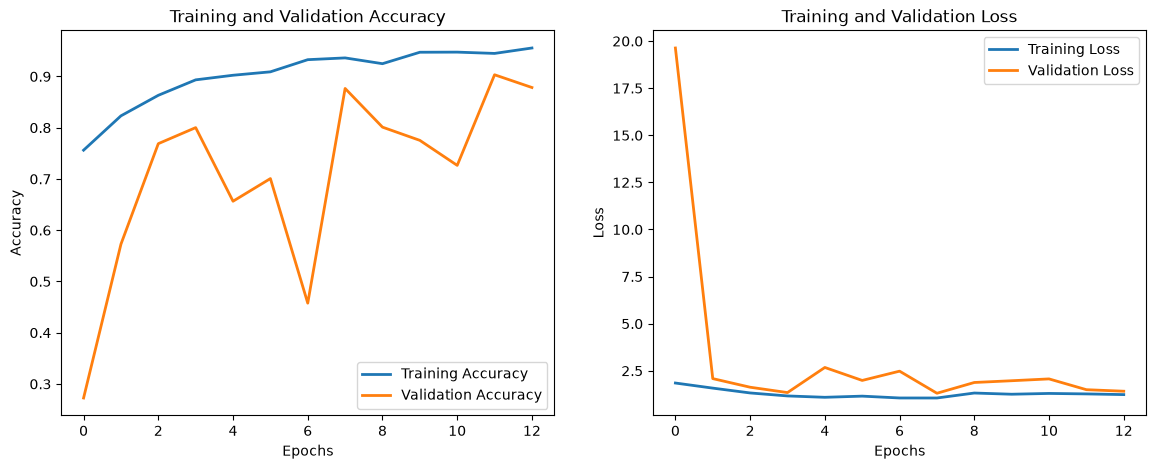

In [10]:
import matplotlib.pyplot as plt

# Retrieve loss and accuracy from history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(14, 5))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs_range, val_acc, label='Validation Accuracy', linewidth=2)
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', linewidth=2)
plt.plot(epochs_range, val_loss, label='Validation Loss', linewidth=2)
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()


--- Classification Report ---
              precision    recall  f1-score   support

      glioma       0.87      0.77      0.82       386
  meningioma       0.71      0.82      0.76       398
     notumor       0.93      0.80      0.86       400
   pituitary       0.86      0.95      0.90       400

    accuracy                           0.83      1584
   macro avg       0.84      0.83      0.83      1584
weighted avg       0.84      0.83      0.84      1584



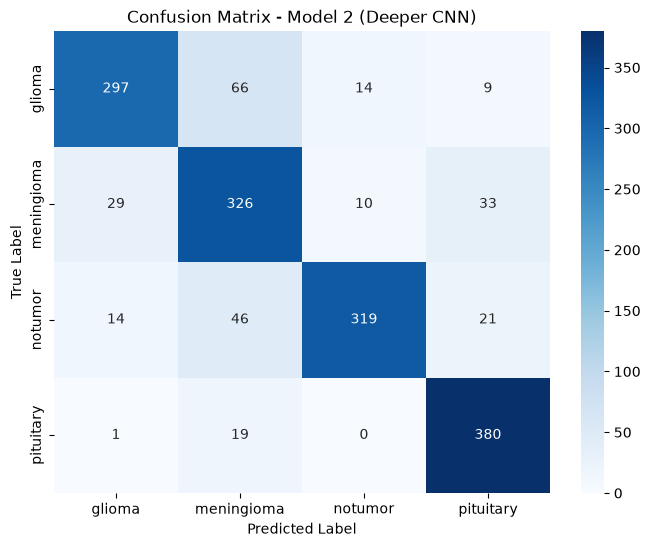

In [11]:
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Get true labels and predictions for test set
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model2.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Print Classification Report (Precision, Recall, F1-score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - Model 2 (Deeper CNN)')
plt.show()


In [12]:
# Save the trained model in Native Keras Format (.keras)
model2.save('model2_deeper_cnn.keras')
print("Model 2 successfully saved as model2_deeper_cnn.keras!")


Model 2 successfully saved as model2_deeper_cnn.keras!
